# EMS741 - Few-Shot Segmentation with Reptile (PyTorch)

This notebook implements a Reptile-style meta-learning approach for few-shot medical image segmentation on the EMS741 coursework dataset using PyTorch.

## 1. Environment and data download

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
print("✅ OpenMP conflict fixed")

!nvidia-smi -L || echo 'No GPU visible (CPU only)'

GPU 0: Tesla T4 (UUID: GPU-60f3ec56-97eb-8d0f-0aa4-305e610aef62)


In [2]:
# Download and extract EMS741 coursework data from Zenodo
import os, zipfile, urllib.request

DATA_URL = 'https://zenodo.org/records/18745413/files/ems741_cw_data.zip?download=1'
ZIP_PATH = 'data.zip'

if not os.path.exists(ZIP_PATH):
    print('Downloading data...')
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    print('Download complete.')

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall('./')

print('Train tasks:', os.listdir('./train'))
print('Val tasks:', os.listdir('./val'))
print('Test tasks:', os.listdir('./test'))

Download complete.
Train tasks: ['task_3', 'task_2', 'task_5', 'task_7']
Val tasks: ['task_6', 'task_4']
Test tasks: ['task_1', 'task_8']


## 2. Imports and basic configuration

In [3]:
import glob, random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 3. Dataset utilities with mask handling

In [4]:
# Dataset for a single task: loads (image, mask) slice pairs
class SliceDataset(Dataset):
    def __init__(self, task_root, min_mask_sum=1.0, allow_empty=True):
        img_dir = os.path.join(task_root, 'images')
        msk_dir = os.path.join(task_root, 'masks')

        img_files = sorted(glob.glob(os.path.join(img_dir, '*.png')))
        msk_files = sorted(glob.glob(os.path.join(msk_dir, '*.png')))
        assert len(img_files) == len(msk_files), 'Mismatch between images and masks'

        pairs = []
        for ip, mp in zip(img_files, msk_files):
            m = np.array(Image.open(mp), dtype=np.float32)
            if m.max() > 1:
                m = m / 255.0
            if (m.sum() >= min_mask_sum) or allow_empty:
                pairs.append((ip, mp))

        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ip, mp = self.pairs[idx]
        img = np.array(Image.open(ip), dtype=np.float32)
        msk = np.array(Image.open(mp), dtype=np.float32)

        if img.max() > 1:
            img = img / 255.0
        if msk.max() > 1:
            msk = msk / 255.0

        img = torch.from_numpy(img).float().unsqueeze(0)
        msk = torch.from_numpy(msk).float().unsqueeze(0)
        return img, msk

## 4. Simple U-Net segmentation model (PyTorch)

In [5]:
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.c1a = nn.Conv2d(in_channels, 32, 3, padding=1)
        self.c1b = nn.Conv2d(32, 32, 3, padding=1)
        self.p1 = nn.MaxPool2d(2)
        self.c2a = nn.Conv2d(32, 64, 3, padding=1)
        self.c2b = nn.Conv2d(64, 64, 3, padding=1)
        self.p2 = nn.MaxPool2d(2)
        self.c3a = nn.Conv2d(64, 128, 3, padding=1)
        self.c3b = nn.Conv2d(128, 128, 3, padding=1)
        self.p3 = nn.MaxPool2d(2)
        self.c4a = nn.Conv2d(128, 256, 3, padding=1)
        self.c4b = nn.Conv2d(256, 256, 3, padding=1)
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.u1a = nn.Conv2d(256 + 128, 128, 3, padding=1)
        self.u1b = nn.Conv2d(128, 128, 3, padding=1)
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.u2a = nn.Conv2d(128 + 64, 64, 3, padding=1)
        self.u2b = nn.Conv2d(64, 64, 3, padding=1)
        self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.u3a = nn.Conv2d(64 + 32, 32, 3, padding=1)
        self.u3b = nn.Conv2d(32, 32, 3, padding=1)
        self.out = nn.Conv2d(32, out_channels, 1)
        self.act = nn.ReLU(inplace=True)
        self.final = nn.Sigmoid() if out_channels == 1 else nn.Softmax(dim=1)

    def forward(self, x):
        x1 = self.act(self.c1a(x)); x1 = self.act(self.c1b(x1)); p1 = self.p1(x1)
        x2 = self.act(self.c2a(p1)); x2 = self.act(self.c2b(x2)); p2 = self.p2(x2)
        x3 = self.act(self.c3a(p2)); x3 = self.act(self.c3b(x3)); p3 = self.p3(x3)
        b = self.act(self.c4a(p3)); b = self.act(self.c4b(b))
        y = self.up1(b); y = torch.cat([y, x3], dim=1); y = self.act(self.u1a(y)); y = self.act(self.u1b(y))
        y = self.up2(y); y = torch.cat([y, x2], dim=1); y = self.act(self.u2a(y)); y = self.act(self.u2b(y))
        y = self.up3(y); y = torch.cat([y, x1], dim=1); y = self.act(self.u3a(y)); y = self.act(self.u3b(y))
        return self.final(self.out(y))

## 5. Task listing and few-shot episode sampling

In [6]:
TRAIN_ROOT = './train'
VAL_ROOT   = './val'
TEST_ROOT  = './test'

def list_tasks(root):
    return sorted([os.path.join(root, d) for d in os.listdir(root) if d.startswith('task_')])

train_tasks = list_tasks(TRAIN_ROOT)
val_tasks   = list_tasks(VAL_ROOT)
test_tasks  = list_tasks(TEST_ROOT)

print('Train tasks:', train_tasks)
print('Val tasks:', val_tasks)
print('Test tasks:', test_tasks)

Train tasks: ['./train/task_2', './train/task_3', './train/task_5', './train/task_7']
Val tasks: ['./val/task_4', './val/task_6']
Test tasks: ['./test/task_1', './test/task_8']


In [7]:
def sample_task_episode(task_root, k_support=4, k_query=4, allow_empty=True, min_mask_sum=1.0):
    ds = SliceDataset(task_root, min_mask_sum=min_mask_sum, allow_empty=allow_empty)
    n = len(ds)
    if n == 0:
        raise ValueError(f'No usable slices in {task_root}')
    idxs = np.random.permutation(n)
    k_total = min(n, k_support + k_query)
    k_s = min(k_support, k_total // 2)
    k_q = min(k_query, k_total - k_s)
    idx_support = idxs[:k_s]
    idx_query   = idxs[k_s:k_s + k_q]
    xs, ys, xq, yq = [], [], [], []
    for i in idx_support:
        x, y = ds[i]; xs.append(x); ys.append(y)
    for i in idx_query:
        x, y = ds[i]; xq.append(x); yq.append(y)
    xs = torch.stack(xs)
    ys = torch.stack(ys)
    xq = torch.stack(xq) if len(xq) > 0 else None
    yq = torch.stack(yq) if len(yq) > 0 else None
    return xs, ys, xq, yq

xs_tmp, ys_tmp, xq_tmp, yq_tmp = sample_task_episode(train_tasks[0], k_support=2, k_query=2)
print(ys_tmp.sum(dim=(1,2,3)))
print('Support shapes:', xs_tmp.shape, ys_tmp.shape)
if xq_tmp is not None:
    print('Query shapes:', xq_tmp.shape, yq_tmp.shape)
print('Support mask sums:', ys_tmp.sum(dim=(1,2,3)))

tensor([  0., 263.])
Support shapes: torch.Size([2, 1, 192, 192]) torch.Size([2, 1, 192, 192])
Query shapes: torch.Size([2, 1, 192, 192]) torch.Size([2, 1, 192, 192])
Support mask sums: tensor([  0., 263.])


## 6. Reptile inner-loop update (single task)

In [8]:
import copy

def inner_update(model, x_s, y_s, steps=5, lr_inner=1e-3, device=device):
    fast_model = copy.deepcopy(model).to(device)
    opt = torch.optim.SGD(fast_model.parameters(), lr=lr_inner)
    x_s = x_s.to(device)
    y_s = y_s.to(device)
    for _ in range(steps):
        opt.zero_grad()
        out = fast_model(x_s)
        if out.shape != y_s.shape:
            y_s = y_s.view_as(out)
        loss = F.binary_cross_entropy(out, y_s)
        loss.backward()
        opt.step()
    return fast_model

## 7. Reptile outer-loop (meta-training)

In [9]:
def reptile_meta_train(model,
                       train_tasks,
                       meta_iters=120,
                       tasks_per_meta_batch=4,
                       k_support=4,
                       k_query=4,
                       lr_inner=1e-3,
                       lr_meta=0.1,
                       allow_empty=True,
                       min_mask_sum=1.0,
                       device=device):
    print('Starting meta-training...')
    model.to(device)
    model.train()

    meta_loss_history = []
    print('Meta-iterations:', meta_iters)
    for it in range(meta_iters):
        meta_losses = []

        # show which meta-iteration we are on occasionally
        if (it + 1) % 10 == 0:
            print(f"\n=== Meta-iteration {it+1}/{meta_iters} ===")

        # reset pseudo-gradients (for accumulating theta' - theta)
        print('  Sampling tasks and performing inner updates...')
        for p in model.parameters():
            p.grad = torch.zeros_like(p.data)

        used_tasks = random.sample(
            train_tasks,
            k=min(tasks_per_meta_batch, len(train_tasks))
        )

        # optional: show which tasks were sampled
        if (it + 1) % 50 == 0:
            print("Sampled tasks:", [os.path.basename(t) for t in used_tasks])
            
        for t_idx, task_root in enumerate(used_tasks):
            # inner/outer loop per task
            xs, ys, xq, yq = sample_task_episode(
                task_root,
                k_support=k_support,
                k_query=k_query,
                allow_empty=allow_empty,
                min_mask_sum=min_mask_sum,
            )
            print(f"    Task {t_idx+1}/{len(used_tasks)}: support mask sums: {ys.sum(dim=(1,2,3)).tolist()}")
            fast_model = inner_update(
                model, xs, ys,
                steps=5,
                lr_inner=lr_inner,
                device=device
            )
            print(f"    Task {t_idx+1}/{len(used_tasks)}: completed inner updates.")

            if xq is not None and yq is not None:
                xq = xq.to(device); yq = yq.to(device)
                with torch.no_grad():
                    out_q = fast_model(xq)
                    if out_q.shape != yq.shape:
                        yq = yq.view_as(out_q)
                    loss_q = F.binary_cross_entropy(out_q, yq)
                    meta_losses.append(loss_q.item())

                # print per-task query loss occasionally
                if (it + 1) % 50 == 0:
                    print(f"  Task {t_idx+1}/{len(used_tasks)} "
                          f"{os.path.basename(task_root)} "
                          f"query loss: {loss_q.item():.4f}")

            for p, p_fast in zip(model.parameters(), fast_model.parameters()):
                p.grad.data.add_(p_fast.data - p.data)
        print('  Updating meta-model parameters...')
        for p in model.parameters():
            p.grad.data.div_(len(used_tasks))
            p.data.add_(lr_meta * p.grad.data)

        mean_loss = float('nan') if len(meta_losses) == 0 else np.mean(meta_losses)
        meta_loss_history.append(mean_loss)

        # summary line every 10 iterations
        if (it + 1) % 10 == 0:
            print(f"[Meta {it+1}/{meta_iters}] mean query BCE: {mean_loss:.4f}")

        # quick sanity on parameter norm every 50 iters
        if (it + 1) % 50 == 0:
            with torch.no_grad():
                total_norm = 0.0
                for p in model.parameters():
                    total_norm += p.data.norm().item() ** 2
                total_norm = total_norm ** 0.5
            print(f"  Parameter L2 norm: {total_norm:.3f}")

    return meta_loss_history

meta_model = SimpleUNet(in_channels=1, out_channels=1)
reptile_meta_train(meta_model, train_tasks=train_tasks, meta_iters=400, tasks_per_meta_batch=4, k_support=4, k_query=4, lr_inner=3e-3, lr_meta=0.1, allow_empty=False, min_mask_sum=1.0, device=device)

Starting meta-training...
Meta-iterations: 400
  Sampling tasks and performing inner updates...
    Task 1/4: support mask sums: [1423.01171875, 2225.431396484375, 864.2430419921875, 1175.180419921875]
    Task 1/4: completed inner updates.
    Task 2/4: support mask sums: [873.7803955078125, 1574.5294189453125, 1025.156982421875, 381.95684814453125]
    Task 2/4: completed inner updates.
    Task 3/4: support mask sums: [820.0156860351562, 462.8039245605469, 3156.078369140625, 1167.7686767578125]
    Task 3/4: completed inner updates.
    Task 4/4: support mask sums: [1031.12548828125, 1092.97265625, 621.36865234375, 633.4588623046875]
    Task 4/4: completed inner updates.
  Updating meta-model parameters...
  Sampling tasks and performing inner updates...
    Task 1/4: support mask sums: [2214.6904296875, 378.0196228027344, 37.764705657958984, 1566.9569091796875]
    Task 1/4: completed inner updates.
    Task 2/4: support mask sums: [410.86669921875, 1535.0, 351.52154541015625, 290

[np.float64(0.7260862439870834),
 np.float64(0.7249628305435181),
 np.float64(0.7246069461107254),
 np.float64(0.7239570617675781),
 np.float64(0.724087119102478),
 np.float64(0.7229549288749695),
 np.float64(0.7230028510093689),
 np.float64(0.7223150432109833),
 np.float64(0.7215960919857025),
 np.float64(0.7216099500656128),
 np.float64(0.721831738948822),
 np.float64(0.7208345532417297),
 np.float64(0.7206573188304901),
 np.float64(0.72034852206707),
 np.float64(0.7199282646179199),
 np.float64(0.7198159098625183),
 np.float64(0.7192071080207825),
 np.float64(0.7186069488525391),
 np.float64(0.71781225502491),
 np.float64(0.7179155349731445),
 np.float64(0.7173115164041519),
 np.float64(0.7171733677387238),
 np.float64(0.7159027457237244),
 np.float64(0.7163577824831009),
 np.float64(0.7156990170478821),
 np.float64(0.7153588384389877),
 np.float64(0.7152145504951477),
 np.float64(0.7143615335226059),
 np.float64(0.714377149939537),
 np.float64(0.7143206000328064),
 np.float64(0.713

## 8. Few-shot adaptation and evaluation (Dice score)

In [10]:
def dice_score(pred, target, eps=1e-6):
    p = (pred > 0.5).float()
    t = target.float()
    inter = (p * t).sum(dim=(1,2,3))
    union = p.sum(dim=(1,2,3)) + t.sum(dim=(1,2,3))
    dice = (2 * inter + eps) / (union + eps)
    return dice.mean().item()

def few_shot_adapt_and_eval(model, task_root, n_shot=4, steps=10, lr_inner=1e-3, device=device):
    ds = SliceDataset(task_root, min_mask_sum=1.0, allow_empty=False)
    n = len(ds)
    if n <= n_shot:
        raise ValueError(f'Not enough slices with foreground in {task_root}')
    idxs = np.random.permutation(n)
    support_idx = idxs[:n_shot]
    query_idx   = idxs[n_shot:]
    xs, ys, xq_list, yq_list = [], [], [], []
    for i in support_idx:
        x, y = ds[i]; xs.append(x); ys.append(y)
    for i in query_idx:
        x, y = ds[i]; xq_list.append(x); yq_list.append(y)
    xs = torch.stack(xs).to(device)
    ys = torch.stack(ys).to(device)
    adapted = copy.deepcopy(model).to(device)
    opt = torch.optim.SGD(adapted.parameters(), lr=lr_inner)
    for _ in range(steps):
        opt.zero_grad()
        out_s = adapted(xs)
        if out_s.shape != ys.shape:
            ys = ys.view_as(out_s)
        loss = F.binary_cross_entropy(out_s, ys)
        loss.backward()
        opt.step()
    batch_size_q = 4
    all_preds, all_targets = [], []
    with torch.no_grad():
        for i in range(0, len(xq_list), batch_size_q):
            xb = torch.stack(xq_list[i:i+batch_size_q]).to(device)
            yb = torch.stack(yq_list[i:i+batch_size_q]).to(device)
            out_q = adapted(xb)
            if out_q.shape != yb.shape:
                yb = yb.view_as(out_q)
            all_preds.append(out_q.cpu())
            all_targets.append(yb.cpu())
            del xb, yb, out_q
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    preds = torch.cat(all_preds, dim=0)
    targets = torch.cat(all_targets, dim=0)
    d = dice_score(preds, targets)
    del adapted
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return d, preds, targets

if len(val_tasks) > 0:
    target_task = val_tasks[0]
    print('Evaluating on:', target_task)
    for shots in [1, 3, 5]:
        d, pq, yq = few_shot_adapt_and_eval(meta_model, target_task, n_shot=shots, steps=10, lr_inner=1e-3, device=device)
        print(f'{shots}-shot Dice: {d:.4f}')
else:
    print('No validation tasks found.')

Evaluating on: ./val/task_4
1-shot Dice: 0.0000
3-shot Dice: 0.0000
5-shot Dice: 0.0000


## 9. Qualitative visualisation of segmentations

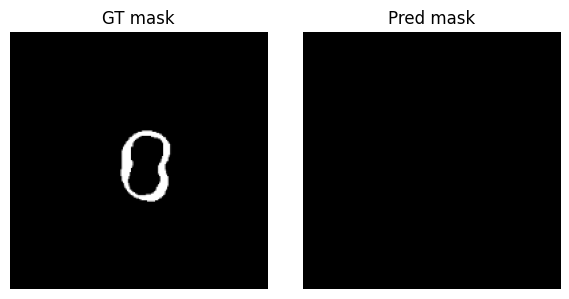

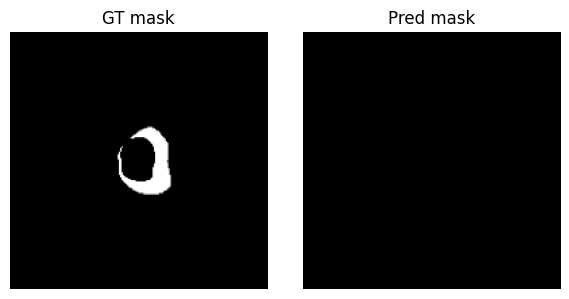

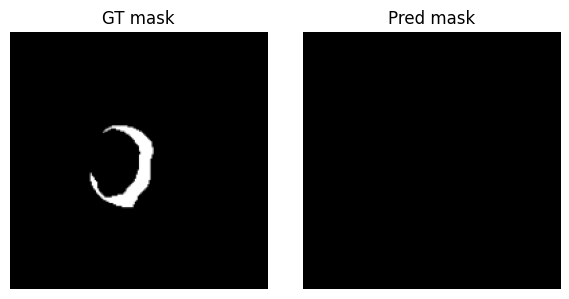

In [11]:
import matplotlib.pyplot as plt

def show_triplet(p, y, idx=0):
    gt  = y[idx, 0].numpy()
    pr  = (p[idx, 0].numpy() > 0.5).astype(np.float32)
    fig, axs = plt.subplots(1, 2, figsize=(6, 3))
    axs[0].imshow(gt, cmap='gray');  axs[0].set_title('GT mask'); axs[0].axis('off')
    axs[1].imshow(pr, cmap='gray');  axs[1].set_title('Pred mask'); axs[1].axis('off')
    plt.tight_layout()
    plt.show()

try:
    for i in range(min(3, pq.shape[0])):
        show_triplet(pq, yq, idx=i)
except NameError:
    print('Run the evaluation cell first to generate pq, yq.')